In [ ]:
import os

# Find the correct path
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

In [ ]:
import os, shutil, urllib.request, gzip
os.chdir('/kaggle/working')
for d in ['data/raw', 'data/processed', 'results/tables', 'results/figures', 'models']:
    os.makedirs(f'/kaggle/working/{d}', exist_ok=True)
scripts_path = '/kaggle/input/datasets/sakshivispute020111/wcs-scripts/'
for f in os.listdir(scripts_path):
    shutil.copy(os.path.join(scripts_path, f), '/kaggle/working/')
out = 'data/raw/facebook_4k.txt'
gz  = 'data/raw/facebook_combined.txt.gz'
if not os.path.exists(out):
    urllib.request.urlretrieve('https://snap.stanford.edu/data/facebook_combined.txt.gz', gz)
    with gzip.open(gz,'rb') as fi, open(out,'wb') as fo:
        shutil.copyfileobj(fi, fo)
    os.remove(gz)
print('Setup done!')

In [ ]:
%run /kaggle/working/step2_graph_construction.py

In [ ]:
import shutil
shutil.copy('/kaggle/working/data/processed/facebook_4k_past_graphs.pkl',
            '/kaggle/working/facebook_4k_past_graphs_BACKUP.pkl')
print('Backup saved!')

In [ ]:
%run /kaggle/working/step3_negative_sampling.py

In [ ]:
%run /kaggle/working/step4_feature_extraction.py

In [1]:
import os
os.chdir('/kaggle/working')
print(os.listdir('/kaggle/working/data/processed/'))

['facebook_4k_features.pkl', 'facebook_4k_dense_shortest.csv', 'facebook_4k_dense_hybrid.csv', 'facebook_4k_sparse_hybrid.csv', 'facebook_4k_moderate_shortest.csv', 'facebook_4k_sparse_shortest.csv', 'facebook_4k_moderate_longest.csv', 'facebook_4k_moderate_hybrid.csv', 'facebook_4k_datasets.pkl', 'facebook_4k_dense_longest.csv', 'facebook_4k_sparse_longest.csv', 'facebook_4k_present.pkl', 'facebook_4k_past_graphs.pkl']


In [2]:
import os, pickle, warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
warnings.filterwarnings("ignore")
os.chdir('/kaggle/working')

def get_models(n_samples):
    models = {
        "LogR": LogisticRegression(max_iter=1000, random_state=42),
        "RF":   RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        "DT":   DecisionTreeClassifier(random_state=42),
        "KNN":  KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        "NB":   GaussianNB(),
        "GB":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    }
    if n_samples <= 20000:
        models["SVM"] = SVC(kernel="rbf", probability=True, random_state=42)
    else:
        print(f"  Skipping SVM (dataset too large: {n_samples} samples)")
    return models

def run_experiment(df, model_name, model, scale=False):
    X = df[["CN","PA","JCI","Salton","Sorenson","HPI","HDI","LHN","AA","RA"]].values
    y = df["label"].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y)
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    return {
        "accuracy":  round(accuracy_score(y_test, y_pred), 6),
        "precision": round(precision_score(y_test, y_pred, average="weighted", zero_division=0), 6),
        "recall":    round(recall_score(y_test, y_pred, average="weighted", zero_division=0), 6),
        "f1_score":  round(f1_score(y_test, y_pred, average="weighted", zero_division=0), 6),
        "roc_auc":   round(roc_auc_score(y_test, y_prob), 6),
    }

# Load features
with open('data/processed/facebook_4k_features.pkl', 'rb') as f:
    feature_store = pickle.load(f)

rows = []
for density_level, strategies in feature_store.items():
    for strat_label, df in strategies.items():
        n_samples = len(df)
        models = get_models(n_samples)
        print(f"\n[{density_level.upper()}] [{strat_label.upper()}] {n_samples} samples")
        for model_name, model in models.items():
            scale = model_name in {"LogR", "KNN"}
            try:
                metrics = run_experiment(df, model_name, model, scale=scale)
                rows.append({"density": density_level, "strategy": strat_label,
                             "model": model_name, **metrics})
                print(f"  {model_name}: F1={metrics['f1_score']:.4f} AUC={metrics['roc_auc']:.4f}")
            except Exception as e:
                print(f"  {model_name}: FAILED — {e}")

results_df = pd.DataFrame(rows)
os.makedirs('results/tables', exist_ok=True)
results_df.to_csv('results/tables/facebook_4k_results.csv', index=False)
print("\n✓ Results saved!")
print(results_df.groupby(['density','strategy'])['f1_score'].max().to_string())

  Skipping SVM (dataset too large: 168392 samples)

[SPARSE] [SHORTEST] 168392 samples
  LogR: F1=0.5807 AUC=0.6441
  RF: F1=0.6029 AUC=0.6437
  DT: F1=0.6028 AUC=0.6435
  KNN: F1=0.5566 AUC=0.5877
  NB: F1=0.4131 AUC=0.5520
  GB: F1=0.6034 AUC=0.6443
  Skipping SVM (dataset too large: 168392 samples)

[SPARSE] [LONGEST] 168392 samples
  LogR: F1=0.6093 AUC=0.6784
  RF: F1=0.6285 AUC=0.6789
  DT: F1=0.6285 AUC=0.6789
  KNN: F1=0.4975 AUC=0.5226
  NB: F1=0.4014 AUC=0.5868
  GB: F1=0.6284 AUC=0.6786
  Skipping SVM (dataset too large: 168392 samples)

[SPARSE] [HYBRID] 168392 samples
  LogR: F1=0.5818 AUC=0.6492
  RF: F1=0.6082 AUC=0.6497
  DT: F1=0.6080 AUC=0.6495
  KNN: F1=0.5830 AUC=0.6019
  NB: F1=0.4213 AUC=0.5520
  GB: F1=0.6086 AUC=0.6505
  Skipping SVM (dataset too large: 88234 samples)

[MODERATE] [SHORTEST] 88234 samples
  LogR: F1=0.8554 AUC=0.9125
  RF: F1=0.8335 AUC=0.8966
  DT: F1=0.7886 AUC=0.7908
  KNN: F1=0.8476 AUC=0.8913
  NB: F1=0.7878 AUC=0.8837
  GB: F1=0.8653 AUC=0.

In [3]:
import os
os.chdir('/kaggle/working')
%run /kaggle/working/step6_visualizations.py


══════════════════════════════════════════════════
Generating figures: facebook_4k
══════════════════════════════════════════════════
  ✓ Saved results/figures/facebook_4k_f1_comparison_GB.png
  ✓ Saved results/figures/facebook_4k_f1_comparison_RF.png
  ✓ Saved results/figures/facebook_4k_f1_comparison_LogR.png
  ✓ Saved results/figures/facebook_4k_roc_auc_heatmap_sparse.png
  ✓ Saved results/figures/facebook_4k_roc_auc_heatmap_moderate.png
  ✓ Saved results/figures/facebook_4k_roc_auc_heatmap_dense.png
  ✓ Saved results/figures/facebook_4k_density_progression_GB.png
  ✓ Saved results/figures/facebook_4k_density_progression_RF.png
  ✓ Saved results/figures/facebook_4k_correlation_matrices.png
  ✓ Saved results/figures/facebook_4k_hybrid_buckets.png
⚠  Skipping facebook_1k — run step5 first

✓ Step 6 complete. All figures saved to results/figures/


In [4]:
import shutil
os.chdir('/kaggle/working')

# Zip everything
shutil.make_archive('wcs_results', 'zip', '/kaggle/working', 'results')
print('Zipped!')
print('Files in results:')
for root, dirs, files in os.walk('/kaggle/working/results'):
    for f in files:
        print(' ', f)

Zipped!
Files in results:
  facebook_4k_results.csv
  facebook_4k_correlation_matrices.png
  facebook_4k_roc_auc_heatmap_dense.png
  facebook_4k_hybrid_buckets.png
  facebook_4k_density_progression_GB.png
  facebook_4k_density_progression_RF.png
  facebook_4k_f1_comparison_RF.png
  facebook_4k_roc_auc_heatmap_moderate.png
  facebook_4k_roc_auc_heatmap_sparse.png
  facebook_4k_f1_comparison_LogR.png
  facebook_4k_f1_comparison_GB.png


In [7]:
import pandas as pd
import os
os.chdir('/kaggle/working')

results_df = pd.read_csv('results/tables/facebook_4k_results.csv')

# Best model per density+strategy
comparison = results_df.groupby(['density','strategy']).agg(
    best_f1=('f1_score','max'),
    best_auc=('roc_auc','max'),
    best_model=('model', lambda x: x.iloc[results_df.loc[x.index,'f1_score'].argmax()])
).reset_index()

# Add base paper results
base_paper = pd.DataFrame({
    'density':   ['sparse','moderate','dense'],
    'strategy':  ['longest','longest','longest'],
    'best_f1':   [0.636123, 0.981376, 0.999149],
    'best_auc':  [0.636368, 0.981515, 0.999165],
    'best_model':['GB','RF','GB'],
    'source':    ['Base Paper','Base Paper','Base Paper']
})

comparison['source'] = 'Our Work'
full_comparison = pd.concat([comparison, base_paper], ignore_index=True)
full_comparison = full_comparison.sort_values(['density','strategy'])

print(full_comparison.to_string(index=False))
full_comparison.to_csv('results/tables/comparison_with_base_paper.csv', index=False)
print('\nSaved to results/tables/comparison_with_base_paper.csv')

 density strategy  best_f1  best_auc best_model     source
   dense   hybrid 0.980736  0.996556         GB   Our Work
   dense  longest 0.998017  0.998297         RF   Our Work
   dense  longest 0.999149  0.999165         GB Base Paper
   dense shortest 0.923484  0.973670         GB   Our Work
moderate   hybrid 0.952454  0.975015         GB   Our Work
moderate  longest 0.979705  0.982518         DT   Our Work
moderate  longest 0.981376  0.981515         RF Base Paper
moderate shortest 0.865257  0.923829         GB   Our Work
  sparse   hybrid 0.608619  0.650462         GB   Our Work
  sparse  longest 0.628464  0.678923         RF   Our Work
  sparse  longest 0.636123  0.636368         GB Base Paper
  sparse shortest 0.603384  0.644299         GB   Our Work

Saved to results/tables/comparison_with_base_paper.csv


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import os
os.chdir('/kaggle/working')

results_df = pd.read_csv('results/tables/facebook_4k_results.csv')

# Plot hybrid vs baselines for GB model
gb = results_df[results_df['model']=='GB'].copy()
densities = ['sparse','moderate','dense']
strategies = ['shortest','longest','hybrid']
colors = {'shortest':'#E07B54','longest':'#5B8DB8','hybrid':'#2CA02C'}

fig, ax = plt.subplots(figsize=(10,6))
x = range(len(densities))
width = 0.25

for i, strat in enumerate(strategies):
    vals = [gb[(gb['density']==d)&(gb['strategy']==strat)]['f1_score'].values[0] 
            for d in densities]
    bars = ax.bar([xi + (i-1)*width for xi in x], vals, width,
                  label=strat.capitalize(), color=colors[strat], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(list(x))
ax.set_xticklabels(['Sparse','Moderate','Dense'])
ax.set_ylabel('F1-Score')
ax.set_title('Gradient Boosting: Hybrid vs Baseline Strategies\n(Facebook 4K Dataset)')
ax.legend(title='Strategy')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

# Add base paper line
base_vals = [0.636123, 0.981376, 0.999149]
ax.plot(list(x), base_vals, 'k--', marker='s', label='Base Paper', linewidth=2)
ax.legend(title='Strategy')

plt.tight_layout()
plt.savefig('results/figures/final_comparison_chart.png', dpi=150)
print('Final chart saved!')
plt.show()

Final chart saved!


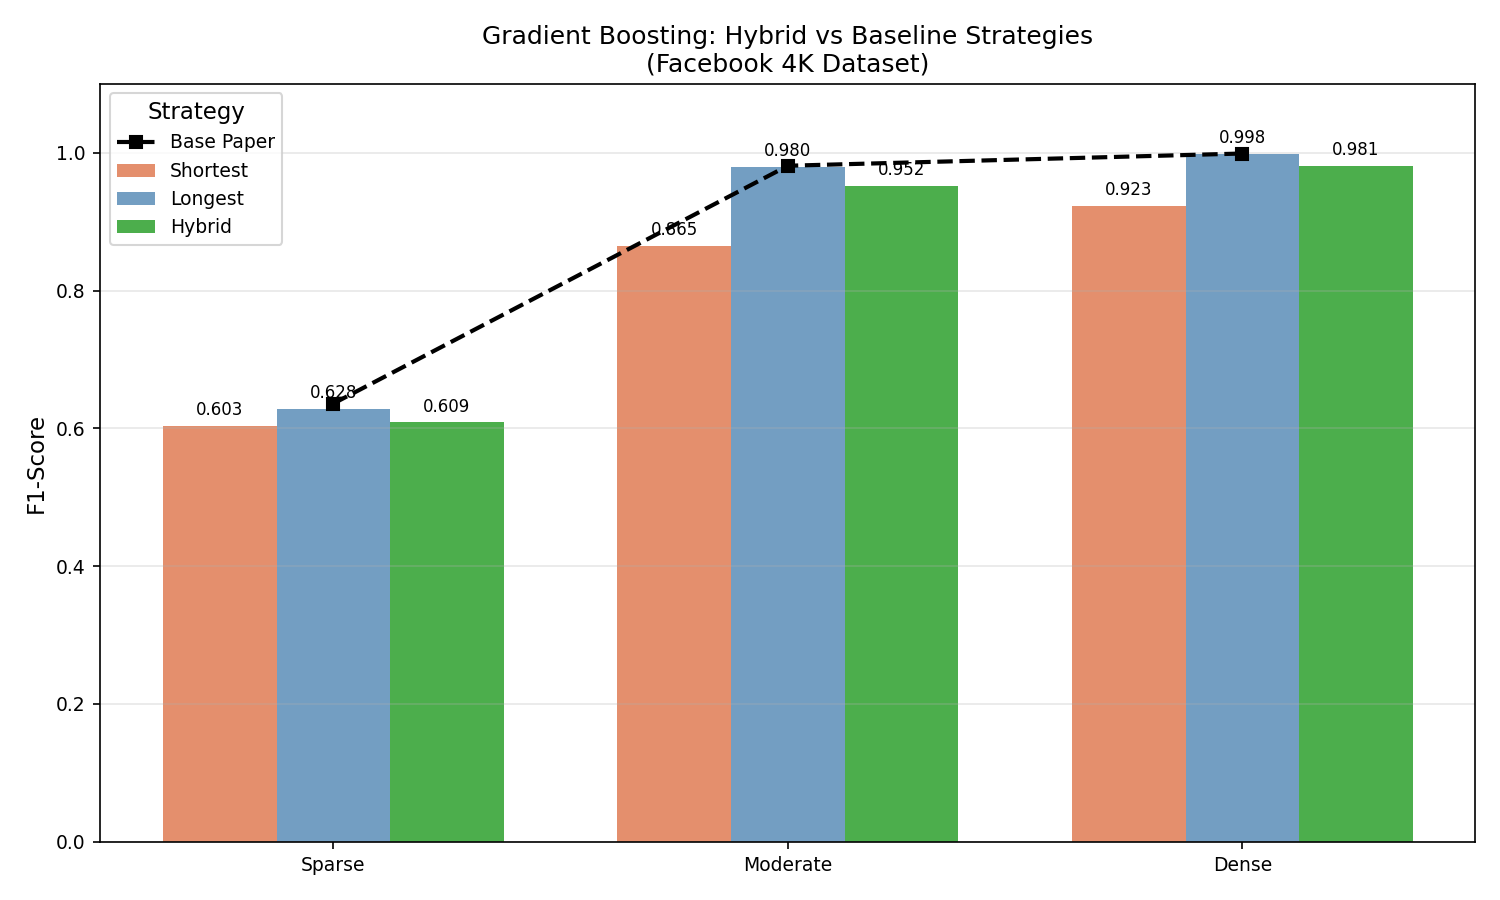

In [10]:
from IPython.display import Image
Image('/kaggle/working/results/figures/final_comparison_chart.png')